In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data from file
pd.options.mode.copy_on_write = True
data = pd.read_json("CDs_and_Vinyl.jsonl", lines=True)

# Create reference and evaluation dataframes
reference_data = data[(data["timestamp"] > "2015-01-01") & (data["timestamp"] < "2019-06-01")].set_index("timestamp").sort_index()
evaluation_data = data[data["timestamp"] >= "2019-06-01"].set_index("timestamp").sort_index()

reference_array = reference_data["rating"].values
rolling = reference_data["rating"].rolling("30D").mean()
significance_threshold = rolling.min()

In [2]:
# Sliding window function
def get_sliding_window_with_newvals(x):
    windows, times, new_values, drift_flag = [], [], [], []
    start_time = x.index[0]
    day = np.timedelta64(1, 'D')
    month = np.timedelta64(30, 'D')
    while start_time + month <= x.index[-1]:
        end_time = start_time + month
        window = x[start_time:end_time]
        new_window_values = x[start_time:start_time + day]["rating"].values
        windows.append(window["rating"].values)
        new_values.append(new_window_values)
        times.append(end_time)
        drift_flag.append(np.mean(window["rating"]) < significance_threshold)
        start_time += day
    return times, windows, new_values, drift_flag

# Sliding window data
sliding_windows = get_sliding_window_with_newvals(evaluation_data)



In [8]:
import scipy

# Redefine SW-UCB for Drift Detection
def sw_ucb(sliding_windows, reference_array, num_trials=100, confidence_level=1.5, drift_threshold=0.1):
    num_arms = len(sliding_windows[1])
    rewards = np.zeros(num_arms)
    selection_counts = np.zeros(num_arms)
    total_rewards = []
    drift_flags = []
    
    for t in range(1, num_trials + 1):
        ucb_values = []
        for arm in range(num_arms):
            if selection_counts[arm] == 0:
                ucb = float('inf')
            else:
                mean_reward = rewards[arm] / selection_counts[arm]
                ucb = mean_reward + confidence_level * np.sqrt(np.log(t) / selection_counts[arm])
            ucb_values.append(ucb)
        
        # Select arm with the highest UCB
        chosen_arm = np.argmax(ucb_values)
        
        # Calculate drift score (Wasserstein distance as an example)
        if len(sliding_windows[1][chosen_arm]) > 0:
            drift_score = scipy.stats.wasserstein_distance(reference_array, sliding_windows[1][chosen_arm])
        else:
            drift_score = 0
        
        # Reward is the drift score, drift flag if score > threshold
        reward = drift_score
        drift_flags.append(drift_score > drift_threshold)
        
        # Update rewards and selection counts
        rewards[chosen_arm] += reward
        selection_counts[chosen_arm] += 1
        total_rewards.append(reward)
    
    return np.array(total_rewards), selection_counts, drift_flags

In [9]:
# Redefine Discounted UCB for Drift Detection
def discounted_ucb(sliding_windows, reference_array, num_trials=100, confidence_level=1.5, discount_factor=0.9, drift_threshold=0.1):
    num_arms = len(sliding_windows[1])
    discounted_rewards = np.zeros(num_arms)
    discounted_counts = np.zeros(num_arms)
    total_rewards = []
    drift_flags = []
    
    for t in range(1, num_trials + 1):
        ucb_values = []
        for arm in range(num_arms):
            if discounted_counts[arm] == 0:
                ucb = float('inf')
            else:
                mean_reward = discounted_rewards[arm] / discounted_counts[arm]
                ucb = mean_reward + confidence_level * np.sqrt(np.log(t) / discounted_counts[arm])
            ucb_values.append(ucb)
        
        # Select arm with the highest UCB
        chosen_arm = np.argmax(ucb_values)
        
        # Calculate drift score (Wasserstein distance as an example)
        if len(sliding_windows[1][chosen_arm]) > 0:
            drift_score = scipy.stats.wasserstein_distance(reference_array, sliding_windows[1][chosen_arm])
        else:
            drift_score = 0
        
        # Reward is the drift score, drift flag if score > threshold
        reward = drift_score
        drift_flags.append(drift_score > drift_threshold)
        
        # Update rewards and selection counts
        discounted_rewards *= discount_factor
        discounted_counts *= discount_factor
        discounted_rewards[chosen_arm] += reward
        discounted_counts[chosen_arm] += 1
        total_rewards.append(reward)
    
    return np.array(total_rewards), discounted_counts, drift_flags


In [11]:
# Run both algorithms and store results
sw_rewards, sw_selection_counts, sw_drift_flags = sw_ucb(sliding_windows, reference_array)
discounted_rewards, discounted_selection_counts, discounted_drift_flags = discounted_ucb(sliding_windows, reference_array)

# Compare drift flags
def compare_drift_detection(sw_drift_flags, discounted_drift_flags, sliding_windows):
    actual_drift_flags = sliding_windows[3]  # True drift flags from sliding window function
    metrics = {
        "SW-UCB": {
            "Drift Detection Rate": np.mean([sw_drift_flags[i] == actual_drift_flags[i] for i in range(len(sw_drift_flags))])
        },
        "Discounted UCB": {
            "Drift Detection Rate": np.mean([discounted_drift_flags[i] == actual_drift_flags[i] for i in range(len(discounted_drift_flags))])
        }
    }
    return metrics

drift_comparison = compare_drift_detection(sw_drift_flags, discounted_drift_flags, sliding_windows)

# Print comparison results
for algo, metrics in drift_comparison.items():
    print(f"Algorithm: {algo}")
    for metric, value in metrics.items():
        print(f"  {metric}: {value}")

Algorithm: SW-UCB
  Drift Detection Rate: 1.0
Algorithm: Discounted UCB
  Drift Detection Rate: 1.0


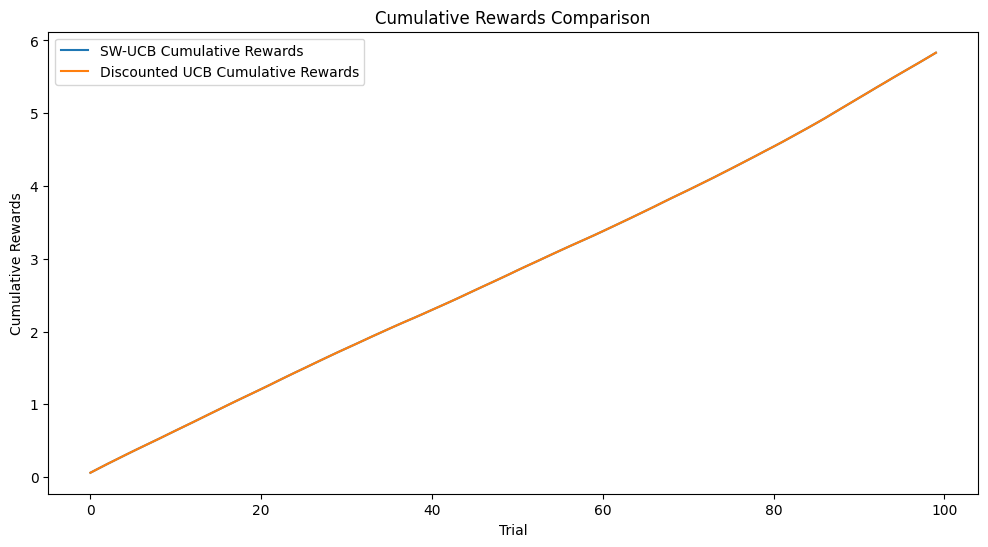

In [12]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(sw_rewards), label="SW-UCB Cumulative Rewards")
plt.plot(np.cumsum(discounted_rewards), label="Discounted UCB Cumulative Rewards")
plt.xlabel("Trial")
plt.ylabel("Cumulative Rewards")
plt.title("Cumulative Rewards Comparison")
plt.legend()
plt.show()

In [13]:
def false_positive_rate(drift_flags, true_flags):
    false_positives = sum((df == True) and (tf == False) for df, tf in zip(drift_flags, true_flags))
    true_negatives = sum((df == False) and (tf == False) for df, tf in zip(drift_flags, true_flags))
    return false_positives / (false_positives + true_negatives) if (false_positives + true_negatives) > 0 else 0

sw_fpr = false_positive_rate(sw_drift_flags, sliding_windows[3])
discounted_fpr = false_positive_rate(discounted_drift_flags, sliding_windows[3])
print(f"SW-UCB False Positive Rate: {sw_fpr}")
print(f"Discounted UCB False Positive Rate: {discounted_fpr}")


SW-UCB False Positive Rate: 0.0
Discounted UCB False Positive Rate: 0.0


In [14]:
def drift_latency(drift_flags, true_flags):
    latency = []
    for i, flag in enumerate(true_flags):
        if flag:
            try:
                first_detection = next(j for j in range(i, len(drift_flags)) if drift_flags[j])
                latency.append(first_detection - i)
            except StopIteration:
                latency.append(len(drift_flags))  # If drift never detected
    return np.mean(latency) if latency else -1

sw_latency = drift_latency(sw_drift_flags, sliding_windows[3])
discounted_latency = drift_latency(discounted_drift_flags, sliding_windows[3])
print(f"SW-UCB Detection Latency: {sw_latency}")
print(f"Discounted UCB Detection Latency: {discounted_latency}")


SW-UCB Detection Latency: 100.0
Discounted UCB Detection Latency: 100.0


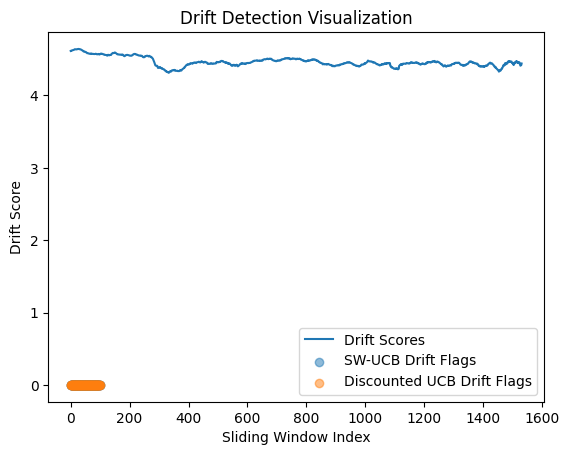

In [15]:
plt.plot([np.mean(sliding_windows[1][i]) for i in range(len(sliding_windows[1]))], label="Drift Scores")
plt.scatter(range(len(sw_drift_flags)), sw_drift_flags, label="SW-UCB Drift Flags", alpha=0.5)
plt.scatter(range(len(discounted_drift_flags)), discounted_drift_flags, label="Discounted UCB Drift Flags", alpha=0.5)
plt.xlabel("Sliding Window Index")
plt.ylabel("Drift Score")
plt.legend()
plt.title("Drift Detection Visualization")
plt.show()
